# Hugging Face Audio Course — Unit 1: Working with Audio Data

A complete, runnable walkthrough of **every concept** in
[Unit 1](https://huggingface.co/learn/audio-course/chapter1/introduction).

| # | Concept | Section |
|---|---------|---------|
| 1–4 | Sampling, Nyquist, decibels, bit depth | §2 |
| 5 | Waveform | §3 |
| 6 | Frequency spectrum (DFT) | §4 |
| 7 | Spectrogram (STFT) | §5 |
| 8 | Mel / log-mel spectrogram | §6 |
| 9–10 | Loading a 🤗 dataset & the `Audio` feature | §7 |
| 11 | Listening | §8 |
| 12 | Resampling | §9 |
| 13 | Filtering by duration | §10 |
| 14 | Feature-extractor preprocessing | §11 |
| 15 | Streaming | §12 |

> **Setup:** run `uv sync` once, then open this notebook with `uv run jupyter lab`.
> **First run** downloads a few small files (the librosa example clip, MINDS-14
> `en-AU`, and the Whisper feature-extractor *config*).

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd   # ipd.Audio(...) plays sound inline

print("librosa", librosa.__version__, "| numpy", np.__version__)

librosa 0.11.0 | numpy 2.4.6


## 2. Audio fundamentals

Audio is a continuous signal. To store it digitally we take measurements at
fixed time steps — **sampling**. Four ideas underpin everything else.

### 2a. Sampling & sampling rate
The **sampling rate** (Hz) is how many samples we capture per second. Common
rates: **44.1 kHz** (CD), **16 kHz** (speech models), **8 kHz** (telephony).
The same 1-second tone contains more samples at higher rates.

  8000 Hz ->   8000 samples in 1 second
 16000 Hz ->  16000 samples in 1 second
 44100 Hz ->  44100 samples in 1 second


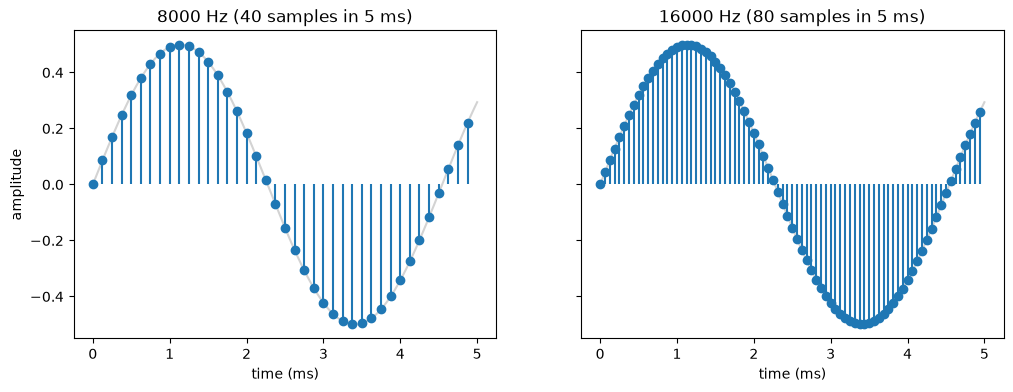

In [3]:
freq = 220.0  # a 220 Hz tone
for sr in (8_000, 16_000, 44_100):
    t = np.linspace(0.0, 1.0, int(sr), endpoint=False)
    tone = 0.5 * np.sin(2 * np.pi * freq * t)
    print(f"{sr:>6d} Hz -> {len(tone):>6d} samples in 1 second")

# Visualise sample density over the first 5 ms
window_s = 0.005
t_ref = np.linspace(0, window_s, 2000)
ref = 0.5 * np.sin(2 * np.pi * freq * t_ref)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, sr in zip(axes, (8_000, 16_000)):
    n = int(sr * window_s)
    ts = np.arange(n) / sr
    ax.plot(t_ref * 1000, ref, color="lightgray", label="continuous signal")
    ax.stem(ts * 1000, 0.5 * np.sin(2 * np.pi * freq * ts), basefmt=" ")
    ax.set_title(f"{sr} Hz ({n} samples in 5 ms)")
    ax.set_xlabel("time (ms)")
axes[0].set_ylabel("amplitude")
plt.show()

### 2b. The Nyquist limit & aliasing
The **Nyquist limit** = `sampling_rate / 2` is the highest frequency a given
sampling rate can faithfully represent. A 6 kHz tone sampled at **8 kHz**
(Nyquist 4 kHz) is **aliased** — it masquerades as `|6000 − 8000| = 2000 Hz`.
At **16 kHz** (Nyquist 8 kHz) it is captured correctly. Run the cell and listen:
the 8 kHz version sounds *lower* in pitch.

In [4]:
f_sig = 6_000

def peak_freq(signal, sr):
    spec = np.abs(np.fft.rfft(signal * np.hanning(len(signal))))
    freqs = np.fft.rfftfreq(len(signal), 1 / sr)
    return float(freqs[np.argmax(spec)])

for sr in (8_000, 16_000):
    t = np.linspace(0.0, 1.0, sr, endpoint=False)
    sig = 0.5 * np.sin(2 * np.pi * f_sig * t)
    detected = peak_freq(sig, sr)
    verdict = "ALIASED!" if detected < f_sig - 1 else "captured correctly"
    print(f"6 kHz sampled at {sr} Hz (Nyquist {sr//2}) -> peak at {detected:.0f} Hz ({verdict})")
    print("   listen:")
    ipd.display(ipd.Audio(sig, rate=sr))

6 kHz sampled at 8000 Hz (Nyquist 4000) -> peak at 2000 Hz (ALIASED!)
   listen:


6 kHz sampled at 16000 Hz (Nyquist 8000) -> peak at 6000 Hz (captured correctly)
   listen:


### 2c. Amplitude & decibels
**Amplitude** is perceived as loudness. Digital audio usually expresses it on a
logarithmic **decibel (dB)** scale: 0 dB is the loudest value, quieter sounds are
negative, and every **−6 dB halves** the amplitude.

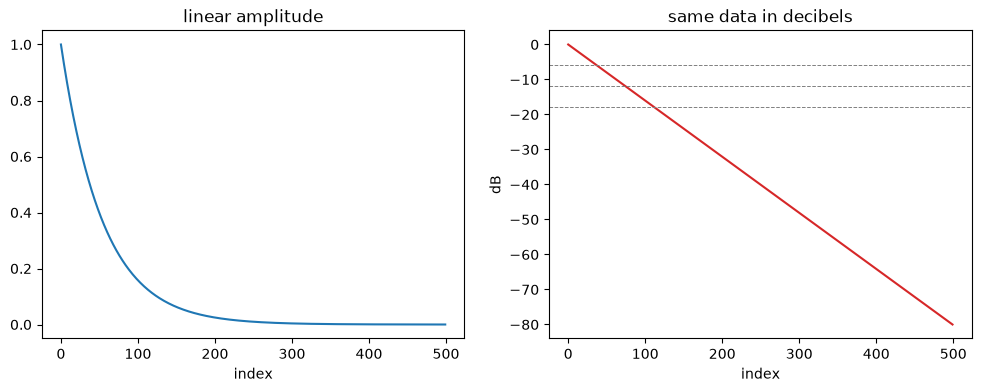

amplitude 1.0 -> 0.0 dB
amplitude 0.5 -> -6.0 dB (≈ -6 dB)


In [5]:
amp = np.logspace(0, -4, 500)               # 1.0 down to 0.0001
amp_db = librosa.amplitude_to_db(amp, ref=1.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(amp);            ax1.set_title("linear amplitude"); ax1.set_xlabel("index")
ax2.plot(amp_db, color="tab:red"); ax2.set_title("same data in decibels")
ax2.set_xlabel("index"); ax2.set_ylabel("dB")
for half in (-6, -12, -18):
    ax2.axhline(half, ls="--", lw=0.7, color="gray")
plt.show()

print("amplitude 1.0 ->", round(float(librosa.amplitude_to_db(np.array([1.0]))[0]), 1), "dB")
print("amplitude 0.5 ->", round(float(librosa.amplitude_to_db(np.array([0.5]))[0]), 1), "dB (≈ -6 dB)")

### 2d. Bit depth & dynamic range
**Bit depth** is how precisely each sample's amplitude is stored. More bits →
more discrete levels → less quantization noise → wider **dynamic range**
(~6 dB per bit). Low bit depth shows up as a visible "staircase".

16-bit ->         65,536 levels, dynamic range ≈  96.3 dB
24-bit ->     16,777,216 levels, dynamic range ≈ 144.5 dB
32-bit ->  4,294,967,296 levels, dynamic range ≈ 192.6 dB


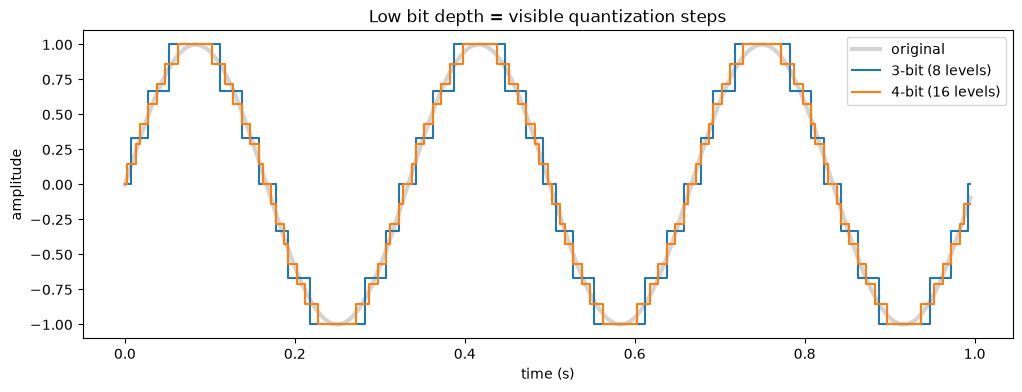

In [6]:
for bits in (16, 24, 32):
    print(f"{bits:>2d}-bit -> {2**bits:>14,d} levels, dynamic range ≈ {6.02*bits:5.1f} dB")

def quantize(x, bits):
    levels = 2 ** bits
    return np.round(x * (levels / 2 - 1)) / (levels / 2 - 1)

t = np.linspace(0, 1, 200, endpoint=False)
clean = np.sin(2 * np.pi * 3 * t)
plt.figure(figsize=(12, 4))
plt.plot(t, clean, color="lightgray", lw=3, label="original")
plt.step(t, quantize(clean, 3), where="mid", label="3-bit (8 levels)")
plt.step(t, quantize(clean, 4), where="mid", label="4-bit (16 levels)")
plt.legend(loc="upper right"); plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Low bit depth = visible quantization steps")
plt.show()

## 3–6. One sound, four representations

We load librosa's built-in **trumpet** clip and view it as a waveform, a
frequency spectrum, a spectrogram, and a mel spectrogram.

In [8]:
# librosa.load downloads the clip on first run (via pooch), decodes it,
# resamples to 22050 Hz by default and mixes to mono.
array, sampling_rate = librosa.load(librosa.ex("trumpet"))
print("shape", array.shape, "| sr", sampling_rate, "| dtype", array.dtype)
print(f"duration {len(array)/sampling_rate:.2f}s, min {array.min():.3f}, max {array.max():.3f}")
ipd.Audio(array, rate=sampling_rate)

shape (117601,) | sr 22050 | dtype float32
duration 5.33s, min -0.685, max 0.632


### 3. Waveform (time domain)
The raw sample values plotted over time.

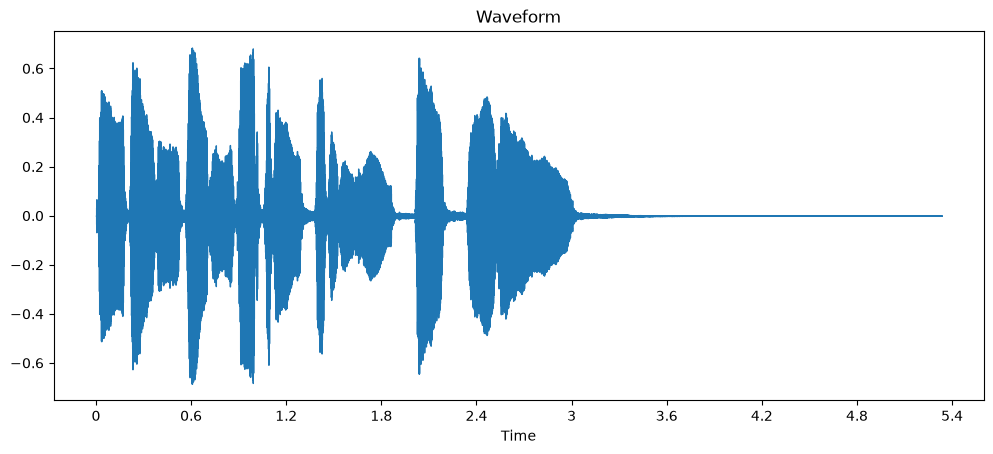

In [9]:
plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)
plt.title("Waveform")
plt.show()

### 4. Frequency spectrum (DFT)
The **Discrete Fourier Transform** turns a slice of the signal into its component
frequencies. We window the slice (to reduce spectral leakage), take the real FFT,
and convert the magnitudes to dB. Peaks are the harmonics of the trumpet note.

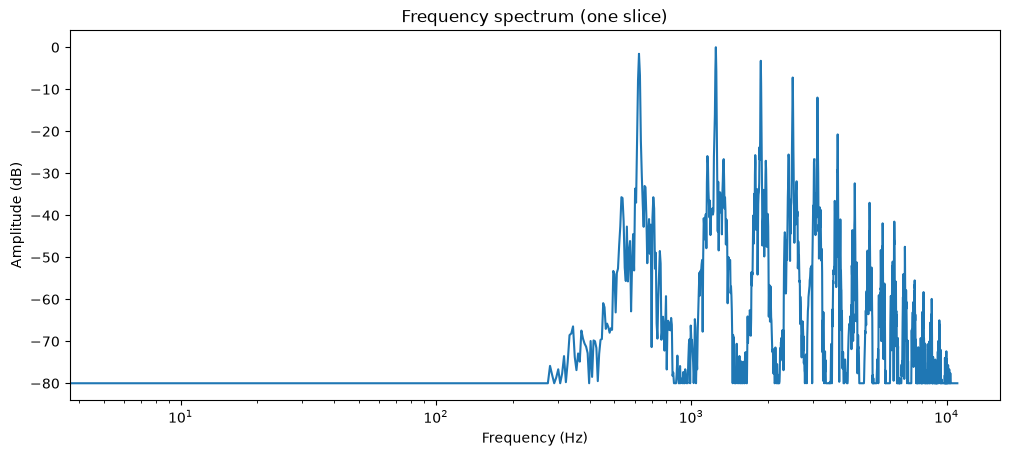

In [10]:
dft_input = array[:4096]
window = np.hanning(len(dft_input))
windowed_input = dft_input * window
dft = np.fft.rfft(windowed_input)
amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)
frequency = librosa.fft_frequencies(sr=sampling_rate, n_fft=len(dft_input))

plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude (dB)"); plt.xscale("log")
plt.title("Frequency spectrum (one slice)")
plt.show()

### 5. Spectrogram (STFT)
The **Short-Time Fourier Transform** computes a spectrum for many short windows,
showing how frequency content evolves over time: x = time, y = frequency,
colour = amplitude.

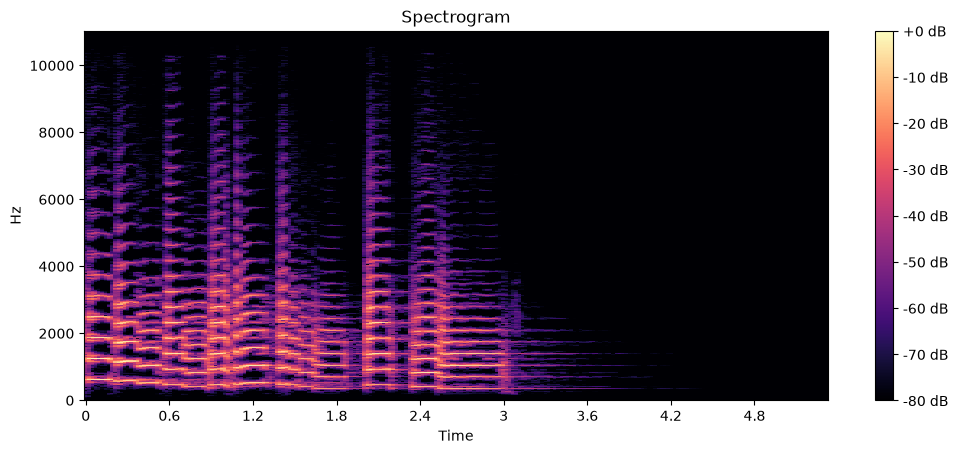

In [11]:
D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
plt.figure().set_figwidth(12)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz", sr=sampling_rate)
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

### 6. Mel spectrogram
A **mel spectrogram** maps frequencies onto the **mel scale**, which approximates
how humans perceive pitch. Expressed in dB it becomes a **log-mel spectrogram** —
the input most speech models actually consume.

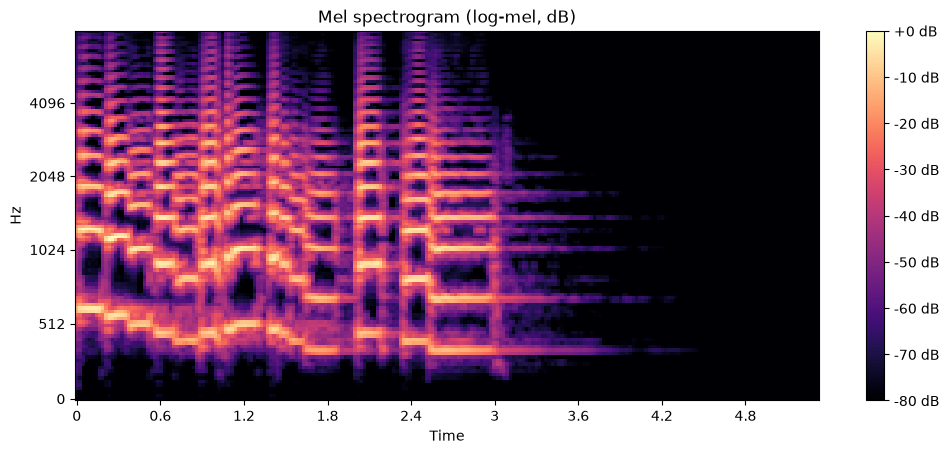

In [12]:
S = librosa.feature.melspectrogram(y=array, sr=sampling_rate, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)
plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sampling_rate, fmax=8000)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel spectrogram (log-mel, dB)")
plt.show()

## 7. Loading a 🤗 audio dataset (MINDS-14)

[MINDS-14](https://huggingface.co/datasets/PolyAI/minds14) contains recordings of
people asking an e-banking system questions, labelled by **intent**. We use the
Australian-English (`en-AU`) split.

In [13]:
from datasets import load_dataset, Audio

def load_minds14():
    kwargs = dict(path="PolyAI/minds14", name="en-AU", split="train")
    try:
        return load_dataset(**kwargs)
    except Exception:
        # script-based datasets need trust_remote_code=True on datasets 3.x
        return load_dataset(**kwargs, trust_remote_code=True)

minds = load_minds14()
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 654
})

### The `Audio` feature
The `audio` column decodes lazily into a dict with three keys:
`array` (the samples), `sampling_rate`, and `path`.

In [14]:
example = minds[0]
audio = example["audio"]
print("keys:", list(audio.keys()))
print("array shape:", audio["array"].shape)
print("sampling_rate:", audio["sampling_rate"], "Hz")   # 8000 Hz originally
print("path:", audio["path"])

id2label = minds.features["intent_class"].int2str
print("intent of example 0:", id2label(example["intent_class"]))
print("\nfeatures:\n", minds.features)

keys: ['path', 'array', 'sampling_rate']
array shape: (62415,)
sampling_rate: 8000 Hz
path: response_4.wav
intent of example 0: pay_bill

features:
 {'path': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=8000, mono=True, decode=True, id=None), 'transcription': Value(dtype='string', id=None), 'english_transcription': Value(dtype='string', id=None), 'intent_class': ClassLabel(names=['abroad', 'address', 'app_error', 'atm_limit', 'balance', 'business_loan', 'card_issues', 'cash_deposit', 'direct_debit', 'freeze', 'high_value_payment', 'joint_account', 'latest_transactions', 'pay_bill'], id=None), 'lang_id': ClassLabel(names=['cs-CZ', 'de-DE', 'en-AU', 'en-GB', 'en-US', 'es-ES', 'fr-FR', 'it-IT', 'ko-KR', 'nl-NL', 'pl-PL', 'pt-PT', 'ru-RU', 'zh-CN'], id=None)}


## 8. Listening to audio
With the array + sampling rate we can play it inline.

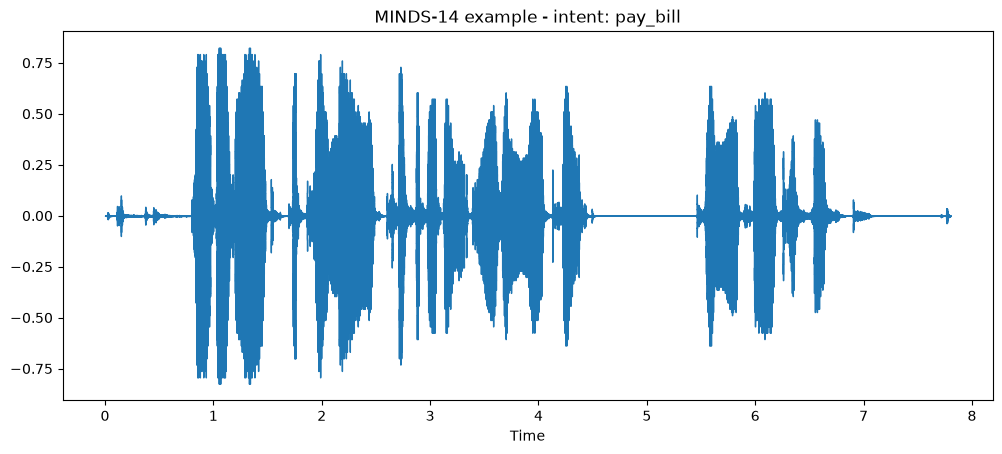

In [15]:
plt.figure().set_figwidth(12)
librosa.display.waveshow(audio["array"], sr=audio["sampling_rate"])
plt.title(f"MINDS-14 example - intent: {id2label(example['intent_class'])}")
plt.show()

ipd.Audio(audio["array"], rate=audio["sampling_rate"])

## 9. Resampling
Most speech models expect **16 kHz**, but MINDS-14 is 8 kHz. `cast_column` with
the `Audio` feature resamples on the fly whenever an example is accessed.

In [16]:
print("before:", minds[0]["audio"]["sampling_rate"], "Hz")
minds = minds.cast_column("audio", Audio(sampling_rate=16_000))
print("after: ", minds[0]["audio"]["sampling_rate"], "Hz")

before: 8000 Hz
after:  16000 Hz


## 10. Filtering by duration
We drop clips longer than 20 seconds. The course reads durations from the file
path; here we compute from the decoded array (equivalent, and works whether audio
is stored as files or inline).

In [17]:
MAX_DURATION_IN_SECONDS = 20.0

def is_audio_length_in_range(input_length):
    return input_length < MAX_DURATION_IN_SECONDS

new_column = [
    librosa.get_duration(y=ex["audio"]["array"], sr=ex["audio"]["sampling_rate"])
    for ex in minds
]
minds = minds.add_column("duration", new_column)
before = minds.num_rows
minds = minds.filter(is_audio_length_in_range, input_columns=["duration"])
print(f"{before} -> {minds.num_rows} examples after filtering")
minds = minds.remove_columns(["duration"])

654 -> 624 examples after filtering


## 11. Pre-processing with a feature extractor
A model's **feature extractor** turns raw audio into the exact input it expects.
Whisper works on fixed **30-second** windows — padded to `max_length` its log-mel
input is **80 × 3000**. Here we follow the course and use `padding=True`, which
pads each clip to the longest in its `map` call, so the frame count reflects the
clip length. (`from_pretrained` downloads only a tiny config — no model weights.)

columns after map: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_features']
input_features shape: (1, 80, 780) -> 80 mel bins x 780 frames
padding=True pads to the longest clip; padding='max_length' -> 3000 frames (30 s)


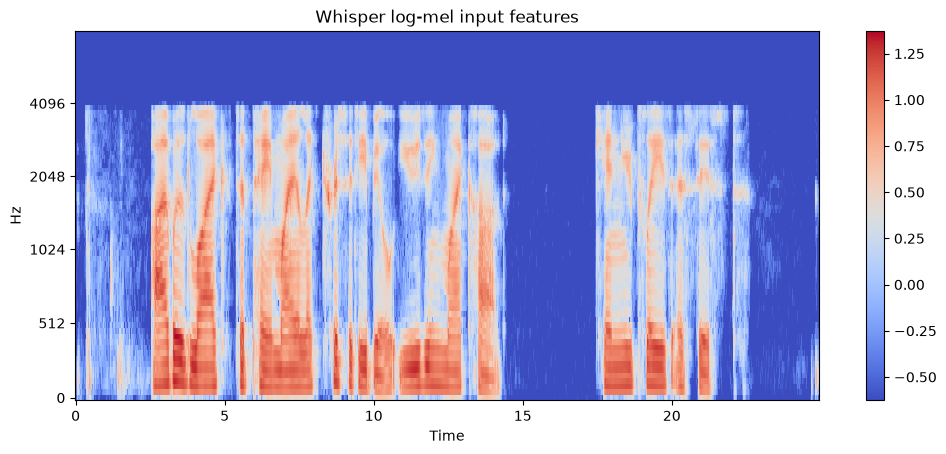

In [18]:
from transformers import WhisperFeatureExtractor

feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")

def prepare_dataset(example):
    audio = example["audio"]
    features = feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"], padding=True
    )
    return features

minds = minds.map(prepare_dataset)
print("columns after map:", minds.column_names)

feats = np.array(minds[0]["input_features"])
print("input_features shape:", feats.shape, "-> 80 mel bins x", feats.shape[-1], "frames")
print("padding=True pads to the longest clip; padding='max_length' -> 3000 frames (30 s)")

log_mel = feats[0] if feats.ndim == 3 else feats
plt.figure().set_figwidth(12)
librosa.display.specshow(log_mel, x_axis="time", y_axis="mel", sr=16_000)
plt.colorbar()
plt.title("Whisper log-mel input features")
plt.show()

## 12. Streaming audio data
For huge datasets, `streaming=True` returns an **`IterableDataset`**: examples are
fetched and processed one-by-one, nothing is stored on disk.

This follows the course and streams **GigaSpeech**, which is *gated* — you must
[accept its terms](https://huggingface.co/datasets/speechcolab/gigaspeech) and run
`huggingface-cli login` first (see the README). Until then the cell **falls back**
to a small public dataset so it still runs.

In [19]:
def stream_dataset():
    try:
        ds = load_dataset("speechcolab/gigaspeech", "xs",
                          streaming=True, trust_remote_code=True)
        return "speechcolab/gigaspeech", ds
    except Exception as exc:
        print("GigaSpeech is gated / not accessible yet:")
        print(" ", type(exc).__name__, str(exc).splitlines()[0][:100])
        print("-> Falling back to hf-internal-testing/librispeech_asr_dummy.\n")
        ds = load_dataset("hf-internal-testing/librispeech_asr_dummy",
                          "clean", streaming=True)
        return "hf-internal-testing/librispeech_asr_dummy", ds

name, streamed = stream_dataset()
print("streaming from:", name)

split = "train" if "train" in streamed else list(streamed.keys())[0]
stream = streamed[split]

first = next(iter(stream))            # one example, on the fly
print("first example keys:", list(first.keys()))
print("sampling_rate:", first["audio"]["sampling_rate"], "Hz")

head = list(stream.take(2))           # preview without downloading everything
print("stream.take(2) ->", len(head), "examples")

GigaSpeech is gated / not accessible yet:
  DatasetNotFoundError Dataset 'speechcolab/gigaspeech' is a gated dataset on the Hub. You must be authenticated to access 
-> Falling back to hf-internal-testing/librispeech_asr_dummy.

streaming from: hf-internal-testing/librispeech_asr_dummy
first example keys: ['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id']
sampling_rate: 16000 Hz
stream.take(2) -> 2 examples


### Why stream?
- **Disk space** — examples load one-by-one; nothing is stored locally, so you can
  use datasets of arbitrary size.
- **Download & processing time** — work happens on the fly; start as soon as the
  first example is ready.
- **Easy experimentation** — try your code on a handful of examples before
  committing to the full dataset.

---
🎉 **That's all of Unit 1.** Next up: Unit 2, *A gentle introduction to audio
applications*.